# Laboratorio 7: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>


### Cuerpo Docente:

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Valentina Abello
- Nombre de alumno 2: Renato Pino

### **Link de repositorio de GitHub:** [Repositorio](https://github.com/Renato-98/MDS7202-1)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

### Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.
- Código que no se pueda ejecutar, no será revisado.



### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

*Escriba su respuesta aquí*
1. Explique cuál es la diferencia entre los datos de entrenamiento y validación.

R:
Los datos de entrenamiento se utilizan para ajustar el modelo, es decir, para que el algoritmo aprenda patrones a partir de los datos. El modelo ajusta sus parámetros internos basándose en los datos.
Por otro lado, los datos de validación se utilizan para evaluar el rendimiento del modelo mientras se está entrenando. Permiten monitorear el desempeño en datos no vistos y ajustar hiperparamétricos (como la regularización o la tasa de aprendizaje). A diferencia de los datos de entrenamiento, los datos de validación no se utilizan para entrenar el modelo directamente, sino para asegurarse de que el modelo generalice bien.

2. Explique cuál es el principal desafío al trabajar en problemas de clasificación con clases desbalanceadas.

R:
El principal desafío en la clasificación con clases desbalanceadas es que los modelos tienden a estar sesgados hacia la clase mayoritaria (o las clases mayoritarias si es un problema multiclase), debido a que hay muchos más ejemplos de esa clase en los datos. Esto puede llevar a un rendimiento pobre en la detección de la clase minoritaria, ya que el modelo prioriza la clase con más ejemplos. Los métodos estándar de evaluación como la precisión (accuracy) pueden ser engañosos, ya que un modelo que predice solo la clase mayoritaria puede tener un alto puntaje de precisión, pero un mal desempeño en la clasificación de la clase minoritaria.

3. En problemas de clasificación, ¿por qué puede ser importante utilizar técnicas de evaluación como la matriz de confusión, la precisión, y el recall en lugar de simplemente usar la precisión global?

R:
La precisión global (que asumo es la accuracy) mide el porcentaje de predicciones correctas, pero no distingue entre las clases. En problemas desbalanceados, generalmente es poco informativa, ya que un modelo que prediga siempre la clase mayoritaria podría tener una alta precisión, aunque no esté capturando bien la clase minoritaria (lo que nos pasaba en minería 😞).

La matriz de confusión no deja ver de forma más detallada los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos, lo que permite una mejor comprensión de cómo se comporta el modelo en cada clase.

La precisión (en inglés, jeje) mide la proporción de verdaderos positivos entre todas las predicciones positivas, mientras que recall mide la proporción de verdaderos positivos entre todos los ejemplos que realmente son positivos. Estas métricas son particularmente útiles para evaluar el rendimiento de un modelo en casos donde los errores en la predicción de una clase minoritaria tienen un alto costo.

4. Explique qué es el undersampling y el oversampling en el contexto de clasificación con clases desbalanceadas.

R:
Undersampling es una técnica que reduce el número de ejemplos en la clase mayoritaria para equilibrar el conjunto de datos. El riesgo de esta técnica es que se podría perder información valiosa de la clase mayoritaria.
Oversampling implica generar más ejemplos de la clase minoritaria (por ejemplo, mediante duplicación o mediante técnicas como SMOTE) para aumentar su proporción en el conjunto de datos. El riesgo del oversampling es que puede generar sobreajuste si se replican ejemplos existentes en exceso.


5. Mencione una métrica que sería útil para evaluar el rendimiento de un modelo en un problema de clasificación con clases desbalanceadas. Explique por qué esa métrica es adecuada.

R:
Una métrica que consideramos siempre útil es el F1-Score, que es la media armonica entre la precisión y el recall. El F1-Score es particularmente adecuado para problemas de clases desbalanceadas porque toma en cuenta tanto la precisión como el recall, penalizando a los modelos que tienen un buen desempeño en una métrica pero no en la otra. Esta métrica ofrece una visión más equilibrada del rendimiento del modelo en problemas donde la clase minoritaria es crítica.

# Parte práctica [48 puntos]

<p align="center">
  <img src="https://i.ibb.co/61L8z0w/renacin-by-volframio-dcirf4l-fullview.jpg"
" width="400">
</p>



Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = '/content/drive/MyDrive/Lab_progra_DS/Lab_7/' # Ajustar al path propio
except:
    print('Ignorando conexión drive-colab')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
# Carga de datos
df = pd.read_csv(path+'stats_players.csv')
df.head()

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,90,95,85,92,93,90,81,76,85,88
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,90,68,71,85,95,88,89,90,74,85
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,96,61,62,78,89,77,79,84,81,83
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,86,69,77,87,94,86,86,84,85,88
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,52,78,25,25,13,16,14,11,47,11


In [ ]:
# Revisar las columnas y sus tipos de datos
print("\nTipos de datos por columna:")
print(df.dtypes)


Tipos de datos por columna:
Name                 object
Nationality          object
National_Position    object
Club_Position        object
Height                int64
Weight                int64
Preffered_Foot       object
Age                   int64
Work_Rate            object
Weak_foot             int64
Skill_Moves           int64
Ball_Control          int64
Dribbling             int64
Marking               int64
Sliding_Tackle        int64
Standing_Tackle       int64
Aggression            int64
Reactions             int64
Interceptions         int64
Vision                int64
Composure             int64
Crossing              int64
Short_Pass            int64
Long_Pass             int64
Acceleration          int64
Speed                 int64
Stamina               int64
Strength              int64
Balance               int64
Agility               int64
Jumping               int64
Heading               int64
Shot_Power            int64
Finishing             int64
Long_Shots         

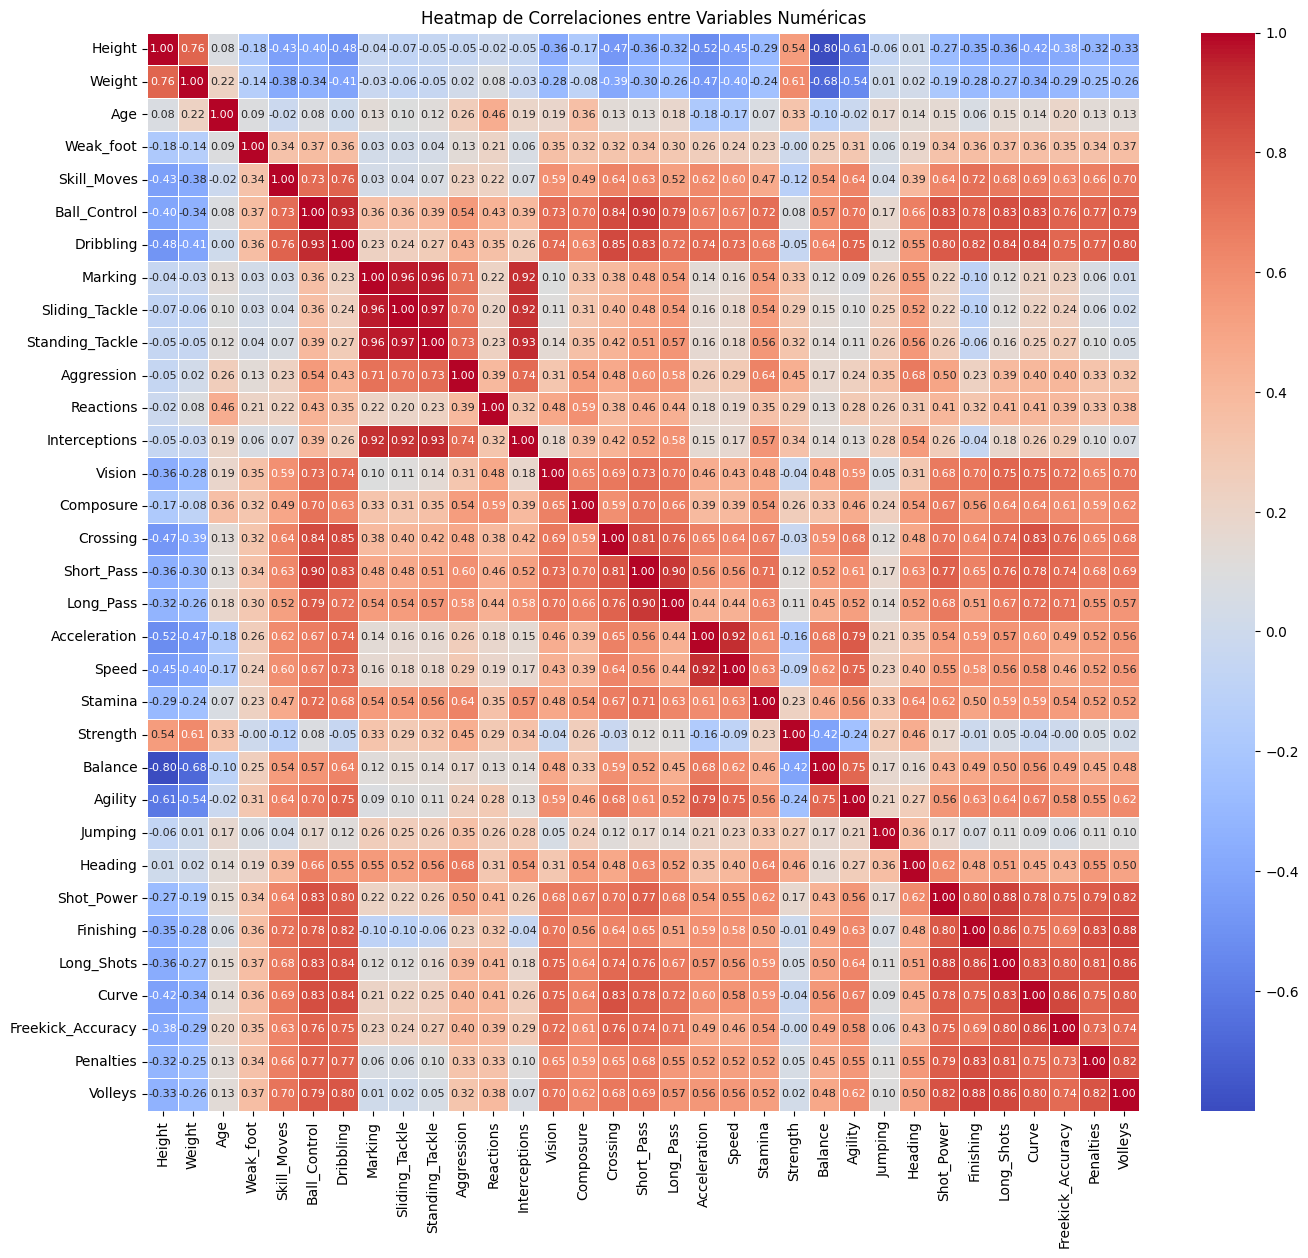

In [ ]:
# Veamos las correlaciones de las variables numericas
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo las columnas con tipo de dato 'int64'
numerical_cols = df.select_dtypes(include=['int64'])

# Calcular la matriz de correlación
correlation_matrix = numerical_cols.corr()

# Configurar el tamaño del gráfico
plt.figure(figsize=(16, 14))

# Crear el heatmap con la matriz de correlación, ajustando el tamaño de la fuente con annot_kws
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f", annot_kws={"size": 8})

# Mostrar el gráfico
plt.title('Heatmap de Correlaciones entre Variables Numéricas')
plt.show()



Como podemos observar por el heatmap, tenemos mucha correlación entre las variables numéricas. Habrá que tenerlo en consideración si en alguna parte nos interesa ver las importancias de cada variable a la hora de clasificar (feature_importance).

A continuacion eliminamos las variables 'name' y 'nationality' porque pueden introducir varios problemas en el modelo sin aportar valor significativo al proceso de clasificación al ser de alta cardinalidad.

In [ ]:
df = df.drop(columns=['Name', 'Nationality'])

## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

In [ ]:
#1. Genere los labels para la clasificación binaria en una variable llamada label.

# Generaramos la variable 'label' basada en 'National_Position'
df['label'] = df['National_Position'].notnull().astype(int)

print(df[['National_Position', 'label']].head(10))

  National_Position  label
0                LS      1
1                RW      1
2                LW      1
3                LS      1
4                GK      1
5                GK      1
6                LS      1
7                RS      1
8               NaN      0
9                GK      1


In [ ]:
#2. ¿Cuántos ejemplos hay por cada clase?

# Contar ejemplos por clase en la variable 'label'
print("\nDistribución de la clase 'label':")
print(df['label'].value_counts())

# Distribucion en porcentaje
print("\nDistribución de la clase 'label' en porcentaje:")
print(df['label'].value_counts(normalize=True) * 100)

# En efecto, clases desbalanceadas XD


Distribución de la clase 'label':
label
0    16513
1     1075
Name: count, dtype: int64

Distribución de la clase 'label' en porcentaje:
label
0    93.887878
1     6.112122
Name: proportion, dtype: float64


In [ ]:
# La variable Work_Rate podria ser tratada como una variable categorica ordinal y por tanto usar un encoder distinto
df.Work_Rate.unique()

array(['High / Low', 'Medium / Medium', 'High / Medium', 'Medium / Low',
       'High / High', 'Medium / High', 'Low / High', 'Low / Medium',
       'Low / Low'], dtype=object)

In [ ]:
#3. Genere un ColumnTransformer en donde especifique las transformaciones que hay que realizar para cada columna

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Definir las columnas que requieren transformaciones
numeric_features = [
    'Height', 'Weight', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle',
    'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure',
    'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength',
    'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots',
    'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys'
]

categorical_features = ['Club_Position', 'Preffered_Foot']

# Definir los valores ordinales en el orden adecuado para 'Work_Rate'
work_rate_order = [
    'Low / Low', 'Low / Medium', 'Low / High',
    'Medium / Low', 'Medium / Medium', 'Medium / High',
    'High / Low', 'High / Medium', 'High / High'
]

# Crear el ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Escalado para variables numéricas
        ('cat', OneHotEncoder(), categorical_features),  # OneHotEncoder para las variables categóricas
        ('ord', OrdinalEncoder(categories=[work_rate_order]), ['Work_Rate'])  # OrdinalEncoder para 'Work_Rate'
    ])

# Ajustar el ColumnTransformer al conjunto de datos
col_transformer.fit(df)

print("ColumnTransformer con OrdinalEncoder para 'Work_Rate' creado y ajustado a los datos.")

ColumnTransformer con OrdinalEncoder para 'Work_Rate' creado y ajustado a los datos.


In [ ]:
df.dtypes

,0
National_Position,object
Club_Position,object
Height,int64
Weight,int64
Preffered_Foot,object
Age,int64
Work_Rate,object
Weak_foot,int64
Skill_Moves,int64
Ball_Control,int64


4. Justificación de las transformaciones:
* Variables numéricas (como Height, Weight, atributos de habilidades como Ball_Control, Dribbling, etc.):
Transformación aplicada: StandardScaler
Justificación: Los valores numéricos suelen tener rangos muy diferentes, por lo que es importante normalizarlos para que estén en la misma escala. Esto ayuda a evitar que algunas características con valores más altos dominen sobre otras, especialmente en modelos sensibles a la escala de los datos, como los árboles de decisión o modelos basados en distancias.

* Variables categóricas sin un orden natural (Club_Position, Preffered_Foot):
Transformación aplicada: OneHotEncoder
Justificación: Estas variables no tienen un orden intrínseco entre sus categorías. Por ejemplo, no podemos asignar un valor numérico que represente el "pie preferido" o la "posición en el club" sin introducir sesgo. Por esta razón, utilizamos la codificación OneHotEncoder, que convierte estas categorías en variables binarias sin imponer una jerarquía.

* Variable categórica ordinal (Work_Rate):
Transformación aplicada: OrdinalEncoder
Justificación: Work_Rate tiene un orden implícito entre sus valores, donde "High / High" representa un mayor esfuerzo en comparación con "Low / Low". Al usar OrdinalEncoder, conservamos esta jerarquía al asignar un valor numérico que refleja este orden natural. Esto es útil para que el modelo entienda la diferencia en la intensidad de trabajo entre los jugadores sin perder la relación entre las categorías.

* Generación de los labels (label basado en National_Position):
Transformación aplicada: Conversión de valores nulos a 0 (no seleccionado) y no nulos a 1 (seleccionado).
Justificación: El atributo National_Position define si un jugador ha sido seleccionado para representar a su país. Aquellos sin una posición nacional fueron marcados como "no seleccionados" (0), mientras que los que tienen una posición nacional fueron etiquetados como "seleccionados" (1).

### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [ ]:
#1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba (la proporción queda a su juicio).

from sklearn.model_selection import train_test_split

# Definir las caracteristicas  y el label
X = df.drop(columns=['label', 'National_Position'])  # Todas las columnas menos la columna 'label'y 'National_Position'
y = df['label']  # La columna 'label'

# Dividir los datos en entrenamiento usando estratificacion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Verificar la proporcion de labels en el conjunto de entrenamiento y prueba
print("Distribución de etiquetas en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de etiquetas en el conjunto de prueba:")
print(y_test.value_counts(normalize=True))


Distribución de etiquetas en el conjunto de entrenamiento:
label
0    0.938916
1    0.061084
Name: proportion, dtype: float64

Distribución de etiquetas en el conjunto de prueba:
label
0    0.938791
1    0.061209
Name: proportion, dtype: float64


In [ ]:
#2. Defina un pipeline llamado pipeline_xgboost y otro llamado pipeline_lightgbm

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Definir el pipeline para XGBoost
pipeline_xgboost = Pipeline(steps=[
    ('preprocessor', col_transformer),  # Usar el ColumnTransformer del preprocesamiento
    ('classifier', XGBClassifier(random_state=42))  # Clasificador XGBoost
])

# Definir el pipeline para LightGBM
pipeline_lightgbm = Pipeline(steps=[
    ('preprocessor', col_transformer),  # Usar el ColumnTransformer del preprocesamiento
    ('classifier', LGBMClassifier(random_state=42))  # Clasificador LightGBM
])


In [ ]:
#3. Entrene los pipelines.

# Pipeline de XGBoost
pipeline_xgboost.fit(X_train, y_train)
print("Pipeline XGBoost entrenado.")

# Pipeline de LightGBM
pipeline_lightgbm.fit(X_train, y_train)
print("Pipeline LightGBM entrenado.")


Pipeline XGBoost entrenado.
[LightGBM] [Info] Number of positive: 752, number of negative: 11559
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2467
[LightGBM] [Info] Number of data points in the train set: 12311, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061084 -> initscore=-2.732483
[LightGBM] [Info] Start training from score -2.732483
Pipeline LightGBM entrenado.


### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

In [ ]:
#1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional)

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Hacer predicciones en el conjunto de prueba con ambos modelos
y_pred_xgboost = pipeline_xgboost.predict(X_test)
y_pred_lightgbm = pipeline_lightgbm.predict(X_test)

# Calcular las metricas para el pipeline de XGBoost
accuracy_xgboost = accuracy_score(y_test, y_pred_xgboost)
precision_xgboost = precision_score(y_test, y_pred_xgboost, pos_label=1)
recall_xgboost = recall_score(y_test, y_pred_xgboost, pos_label=1)

# Calcular las metricas para el pipeline de LightGBM
accuracy_lightgbm = accuracy_score(y_test, y_pred_lightgbm)
precision_lightgbm = precision_score(y_test, y_pred_lightgbm, pos_label=1)
recall_lightgbm = recall_score(y_test, y_pred_lightgbm, pos_label=1)

# Mostrar los resultados para XGBoost
print("Métricas para XGBoost:")
print(f"Accuracy: {accuracy_xgboost:.2f}")
print(f"Precisión: {precision_xgboost:.2f}")
print(f"Recall: {recall_xgboost:.2f}")

# Mostrar los resultados para LightGBM
print("\nMétricas para LightGBM:")
print(f"Accuracy: {accuracy_lightgbm:.2f}")
print(f"Precisión: {precision_lightgbm:.2f}")
print(f"Recall: {recall_lightgbm:.2f}")

# Verificar resultados usando classification_report para ambos modelos
print("\nClassification Report para XGBoost:")
print(classification_report(y_test, y_pred_xgboost, target_names=["No Seleccionado", "Seleccionado"]))

print("\nClassification Report para LightGBM:")
print(classification_report(y_test, y_pred_lightgbm, target_names=["No Seleccionado", "Seleccionado"]))


Métricas para XGBoost:
Accuracy: 0.94
Precisión: 0.53
Recall: 0.15

Métricas para LightGBM:
Accuracy: 0.94
Precisión: 0.54
Recall: 0.12

Classification Report para XGBoost:
                 precision    recall  f1-score   support

No Seleccionado       0.95      0.99      0.97      4954
   Seleccionado       0.53      0.15      0.23       323

       accuracy                           0.94      5277
      macro avg       0.74      0.57      0.60      5277
   weighted avg       0.92      0.94      0.92      5277


Classification Report para LightGBM:
                 precision    recall  f1-score   support

No Seleccionado       0.95      0.99      0.97      4954
   Seleccionado       0.54      0.12      0.20       323

       accuracy                           0.94      5277
      macro avg       0.74      0.56      0.58      5277
   weighted avg       0.92      0.94      0.92      5277



2. Explicación de los valores de accuracy, precisión y recall.

* Accuracy (94%): Ambas versiones de los modelos (XGBoost y LightGBM) alcanzaron un 94% de accuracy. Esto indica que el 94% de las predicciones realizadas por el modelo son correctas. Sin embargo, en un problema desbalanceado como este (con más ejemplos de jugadores no seleccionados), el accuracy no refleja adecuadamente el rendimiento en la clase seleccionada (la clase positiva), ya que predecir correctamente que un jugador no fue seleccionado es mucho más fácil y tiene más peso en esta métrica.

* Precisión (~53-54%): La precisión nos dice que de todos los jugadores que el modelo predijo como seleccionados, solo alrededor del 53-54% realmente lo fueron. Una precisión moderada sugiere que el modelo tiene dificultad para distinguir correctamente a los jugadores seleccionados. Un valor bajo de precisión puede deberse a un alto número de falsos positivos (jugadores no seleccionados que el modelo predijo incorrectamente como seleccionados).

* Recall (15% en XGBoost y 12% en LightGBM): El recall mide cuántos de los jugadores que realmente fueron seleccionados el modelo logró identificar correctamente. Los valores bajos de 15% y 12% en XGBoost y LightGBM, respectivamente, indican que el modelo está perdiendo la mayoría de los jugadores seleccionados. Esto significa que, de todos los jugadores seleccionados, solo un pequeño porcentaje es identificado correctamente.

Al ser la distribución desbalanceada (con muchos más ejemplos de jugadores no seleccionados que seleccionados), las metas son afectadas considerablemente, especialmente precisión y recall. Los modelos tienden a inclinarse hacia la clase mayoritaria (no seleccionados), lo que genera una alta accuracy porque el modelo predice correctamente la clase mayoritaria con frecuencia. Sin embargo, este desbalance también provoca una caída en el recall de la clase minoritaria (seleccionados), ya que el modelo tiene menos ejemplos para aprender a identificar jugadores seleccionados, lo que explica el bajo recall y moderada precisión.

3. Explicación de la métrica más adecuada y conclusión sobre el mejor modelo

* Dado que estamos tratando con un problema de clasificación desbalanceada y estamos más interesados en identificar correctamente a los jugadores seleccionados (clase positiva), las métricas más adecuadas para evaluar el modelo en este contexto son la precisión y el recall de la clase seleccionada.

* Si se busca minimizar los falsos positivos (es decir, jugadores no seleccionados que el modelo predice incorrectamente como seleccionados), la precisión es una métrica clave. En este caso, ambos modelos tienen una precisión similar (~53-54%).

* Si lo más importante es no perder ningún jugador seleccionado (es decir, maximizar la identificación de jugadores seleccionados), el recall sería la métrica más crítica. En este caso, ambos modelos tienen un recall bajo, siendo XGBoost ligeramente mejor con 15% frente a 12% de LightGBM.

* Y si queremos un equilibrio entre estas métricas, el F1-Score es la métrica en la que deberíamos fijarnos, como lo mencionamos en las respuestas de la parte teórica

Conclusión sobre el mejor modelo:

En este caso, el modelo XGBoost parece tener un desempeño ligeramente superior en términos de recall, identificando un poco más de jugadores seleccionados en comparación con LightGBM (15% frente a 12%). Sin embargo, ambos modelos tienen un rendimiento similar en precisión y accuracy. Por lo tanto, si nuestro objetivo es maximizar el recall, XGBoost sería la mejor opción por un pelo, jeje.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

In [ ]:
#1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable label.

# Creamos una copia del dataframe para trabajar en este nuevo problema
df_posiciones = df.copy()

# Definir los grupos de posiciones
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']

# Funcion para asignar etiquetas a las posiciones
def etiquetar_posicion(posicion):
    if posicion in ataque:
        return 'ataque'
    elif posicion in central_ataque:
        return 'central_ataque'
    elif posicion in central:
        return 'central'
    elif posicion in central_defensa:
        return 'central_defensa'
    elif posicion in defensa:
        return 'defensa'
    elif posicion in arquero:
        return 'arquero'
    else:
        return None  # Para posiciones 'Sub' y 'Res', dejarlas fuera

# Aplicar la funcion de etiquetado
df_posiciones['label'] = df_posiciones['Club_Position'].apply(etiquetar_posicion)

# Filtrar los jugadores sin etiquetas ('Sub', 'Res' que fueron marcados como None)
df_posiciones = df_posiciones[df_posiciones['label'].notnull()]

# Mostrar las primeras filas del nuevo dataframe con las etiquetas
print(df_posiciones[['Club_Position', 'label']].head())



  Club_Position           label
0            LW  central_ataque
1            RW  central_ataque
2            LW  central_ataque
3            ST          ataque
4            GK         arquero


In [ ]:
#2. Cuente cuántos por clase quedan.

print("\nDistribución de jugadores por posición:")
print(df_posiciones['label'].value_counts())



Distribución de jugadores por posición:
label
defensa            1180
central             907
arquero             632
central_ataque      581
ataque              430
central_defensa     209
Name: count, dtype: int64


In [ ]:
#3.1 Como ahora excluiremos la variable Club_Position, defemos modificar el ColumnTransformer solo un poco

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

numeric_features = [
    'Height', 'Weight', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle',
    'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure',
    'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength',
    'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots',
    'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys'
]

categorical_features = ['Preffered_Foot'] # Excluimos 'Club_Position'

# Definir los valores ordinales en el orden adecuado para 'Work_Rate'
work_rate_order = [
    'Low / Low', 'Low / Medium', 'Low / High',
    'Medium / Low', 'Medium / Medium', 'Medium / High',
    'High / Low', 'High / Medium', 'High / High'
]

# Crear el ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Escalado para variables numéricas
        ('cat', OneHotEncoder(), categorical_features),  # OneHotEncoder para las variables categóricas
        ('ord', OrdinalEncoder(categories=[work_rate_order]), ['Work_Rate'])  # OrdinalEncoder para 'Work_Rate'
    ])

# Ajustar el ColumnTransformer al conjunto de datos
col_transformer.fit(df)

print("ColumnTransformer con OrdinalEncoder para 'Work_Rate' creado y ajustado a los datos.")


ColumnTransformer con OrdinalEncoder para 'Work_Rate' creado y ajustado a los datos.


In [ ]:
#3.2 Entrene el nuevo pipeline y ejecute una evaluación de este.

from sklearn.ensemble import RandomForestClassifier # Probare con Random Forest a ver que tal jeje

# Definir caracteristicas (X) y la nueva variable objetivo (y)
X = df_posiciones.drop(columns=['label', 'Club_Position'])  # Excluir la columna de etiqueta y la de posición original
y = df_posiciones['label']

# Dividir los datos training y tesy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

categorical_features = ['Preffered_Foot'] # Ya no esta Club_Position en el dataset
# Crear el pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', col_transformer),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Entrenar el pipeline
pipeline_rf.fit(X_train, y_train)
print("Pipeline de RandomForest entrenado para la predicción de posiciones.")


Pipeline de RandomForest entrenado para la predicción de posiciones.


In [ ]:
from sklearn.metrics import classification_report

# Hacer predicciones en el conjunto de prueba
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluar el modelo
print("\nClassification Report para RandomForestClassifier:")
print(classification_report(y_test, y_pred_rf, target_names=y.unique()))


Classification Report para RandomForestClassifier:
                 precision    recall  f1-score   support

 central_ataque       1.00      1.00      1.00       190
         ataque       0.75      0.82      0.78       129
        arquero       0.54      0.62      0.58       272
        defensa       0.39      0.21      0.28       174
        central       0.41      0.14      0.21        63
central_defensa       0.81      0.97      0.88       354

       accuracy                           0.72      1182
      macro avg       0.65      0.63      0.62      1182
   weighted avg       0.69      0.72      0.70      1182



4. Comente los resultados obtenidos.

El modelo tiene una precisión general(accuaracy) del 72%. Esto es un resultado aceptable pero no excelente, especialmente considerando que se trata de un problema multiclase.

El modelo tiene un desempeño desigual dependiendo de la posicion. Mientras que las posiciones de central_ataque y central_defensa son predichas con alta precision y recall, otras posiciones como defensa y central presentan problemas, con bajos valores tanto de precisionn como de recall, es decir,
algunas clases están siendo bien clasificadas, mientras que otras (como defensa y central) son difíciles de distinguir para el modelo.

*Desbalance en las clases:*

Notamos que hay algunas clases con mayor soporte, como arquero (272 ejemplos) y central_defensa (354 ejemplos), mientras que otras, como central (63 ejemplos), tienen menos representación en los datos. Este desbalance puede influir en el rendimiento del modelo ya que tiene menos datos para aprender a clasificar correctamente algunas posiciones.

Para mejorar el rendimiento del modelo, especialmente en las clases con bajo recall como defensa y central, podriamos considerar probar técnicas como oversampling o undersampling de las clases minoritarias para equilibrar mejor las categorías, o probar con  clasificadores diferentes (como los que ocupamos antes, XGBoost o LightGBM).

Otra opcion sería ajustar los hiperparqmetros del RandomForest para mejorar el balance entre precision y recall, o entrenar un modelo que optimice directamente para recall si lo que mas le interesa a Renacín es identificar correctamente todas las posiciones posibles.

## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

In [ ]:
df = df.drop(columns=['National_Position'])

In [ ]:
#!pip install pycaret[full]

In [ ]:
from pycaret.datasets import get_data
from pycaret.classification import *
import os

os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

#Continuar código aquí
clf = setup(data=df, target='label', session_id=42)

,Description,Value
0,Session id,42
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 37)"
4,Transformed data shape,"(17588, 45)"
5,Transformed train set shape,"(12311, 45)"
6,Transformed test set shape,"(5277, 45)"
7,Numeric features,33
8,Categorical features,3
9,Rows with missing values,0.0%


In [ ]:
# 1. Comparar modelos
best_model = compare_models(include=['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9414,0.8145,0.0731,0.7105,0.1313,0.1213,0.2127,3.2240
catboost,CatBoost Classifier,0.9409,0.8406,0.1063,0.5930,0.1794,0.1640,0.2326,11.8470
et,Extra Trees Classifier,0.9401,0.8080,0.0399,0.7411,0.0749,0.0686,0.1584,2.7400
lightgbm,Light Gradient Boosting Machine,0.9401,0.8283,0.1223,0.5337,0.1973,0.1793,0.2337,4.3850
xgboost,Extreme Gradient Boosting,0.9377,0.8164,0.1117,0.4587,0.1783,0.1585,0.2028,1.1890
dt,Decision Tree Classifier,0.8964,0.5817,0.2232,0.1964,0.2081,0.1531,0.1538,0.4080


Processing:   0%|          | 0/29 [00:00<?, ?it/s]

Según lo solicitado por Jere, de necesitar un modelo rápido y con una baja tasa de falsos positivos, el mejor modelo sería	`Extra Trees Classifier` (`et`) con una **precisión** de **0,7411** y un **tiempo de entrenamiento** (TT) de **2,74 segundos**.

2.

* `'et'`: **Extra Trees Classifier**, es un modelo basado en un conjunto de árboles de decisión, que a diferencia de Random Forest no solo selecciona una submuestra aleatoria de las características para cada árbol, también las divisiones de los nodos son seleccionados de manera aleatoria.

* `'rf'`: **Random Forest Classifier**, es un modelo que genera múltiples árboles de decisión independientes a partir de distintas submuestras de un conjunto de datos, promediando sus predicciones para calcular la predicción final.

* `'dt'`: **Decision Tree Classifier**, también es un modelo basado en árboles de decisión, donde los datos se dividen en ramas basándose en características que optimizan medidas de pureza (como ganancia de información o entropía), cada nodo realiza una decisión basada en una característica y las hojas del árboles representan a las predicciones finales.

In [ ]:
# 3.
# Crear el modelo seleccionado (et)
final_model = create_model('et')

# Evaluar el modelo
evaluate_model(final_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9399,0.7665,0.0526,0.6667,0.0976,0.0893,0.1759
1,0.9407,0.8019,0.0267,1.0000,0.0519,0.0489,0.1584
2,0.9407,0.8098,0.0400,0.7500,0.0759,0.0702,0.1645
3,0.9399,0.8577,0.0400,0.6000,0.0750,0.0679,0.1439
4,0.9399,0.8066,0.0400,0.6000,0.0750,0.0679,0.1439
5,0.9407,0.8033,0.0400,0.7500,0.0759,0.0702,0.1645
6,0.9399,0.8083,0.0400,0.6000,0.0750,0.0679,0.1439
7,0.9415,0.8349,0.0400,1.0000,0.0769,0.0726,0.1940
8,0.9407,0.7742,0.0267,1.0000,0.0519,0.0489,0.1584


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

* **Confusión Matrix:** ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
<center>
<img src='https://drive.google.com/uc?id=1-XR55VSYt4wABySqO9EpLvmZFHHzuhGB' width=400 />
</center>

175 - 148
\begin{align*}
\text{Tasa Verdaderos Positivos} =  \frac{21}{21 + 302} \approx 0,065
\end{align*}

Esto nos indica que el modelo identifica correctamente aproximadamente el 6,5% de los jugadores seleccionados. Esta métrica es bastante baja, especialmente si Jere quiere inventir en jugadores.

\begin{align*}
\text{Tasa Verdaderos Negativos} =  \frac{4946}{4946 + 8} \approx 0,998
\end{align*}

Nos indica que el modelo identifica correctamente aproximadamente el 99,9% de los jugadores no seleccionados.

* **Threshold:** ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?

<center>
<img src='https://drive.google.com/uc?id=1goRUe2jkY_GVyD98nAEC5tUcVNoxdkh2' width=500 />
</center>

De acuerdo al gráfico, podemos observar que el umbra por defecto no es el mejor para este modelo, por lo que para mejorar el rendimiento, es recomendable utilizar 0,19.


* **Feature Importance:** ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?

<center>
<img src='https://drive.google.com/uc?id=1oKZn6IvCwXX17mE3kq4pQ8YeYGM-UmLL' width=500 />
</center>

Las variables con más desempeño serían `'Reactions', 'Composure' y 'Ball_Control'`. Que deben estar muy relacionadas con el comportamiento del jugador.

* **Learning Curve:** ¿El modelo presenta algún problema?

<center>
<img src='https://drive.google.com/uc?id=1-sY2CmcfutOx1PqG9lnfOdVJTdzY8xhO' width=500 />
</center>

Del gráfico, podemos observar que la curva de Training Score es constante e igual a 1, indicándonos que el modelo se ajusta demasiado bien a los datos de entrenamiento, lo que podría significar sobreajuste. Mientras que la curva de Cross Validation Score es también casi constante en 0,94, siendo menor que Training Score, también indicando sobreajuste.

### 2.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

In [ ]:
# 1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]
xgboost = create_model('xgboost')

# 2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]
evaluate_model(xgboost)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9391,0.7906,0.1316,0.5263,0.2105,0.1906,0.2417
1,0.9358,0.8304,0.0533,0.3333,0.0920,0.0764,0.1130
2,0.9326,0.8005,0.0800,0.3000,0.1263,0.1033,0.1284
3,0.9342,0.8251,0.0800,0.3333,0.1290,0.1080,0.1387
4,0.9407,0.8298,0.1333,0.5556,0.2151,0.1961,0.2519
5,0.9407,0.8006,0.1067,0.5714,0.1798,0.1637,0.2289
6,0.9391,0.8319,0.1733,0.5000,0.2574,0.2334,0.2696
7,0.9407,0.8428,0.1600,0.5455,0.2474,0.2260,0.2733
8,0.9407,0.7828,0.1067,0.5714,0.1798,0.1637,0.2289


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

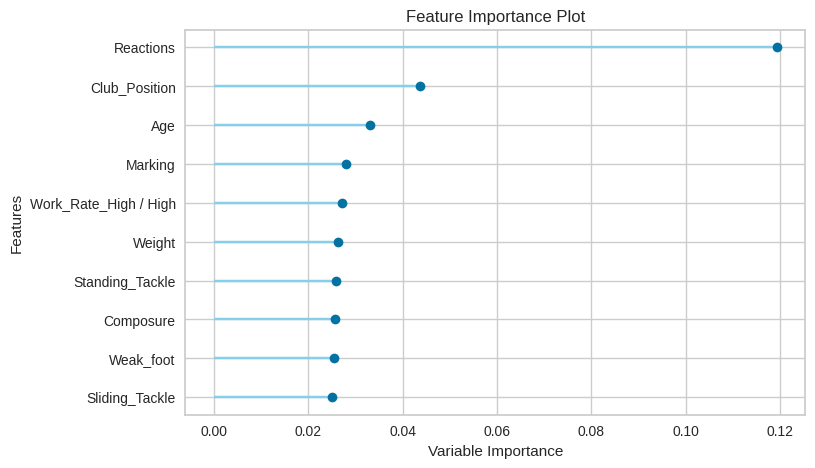

In [ ]:
plot_model(xgboost, plot='feature')

In [ ]:
# 1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]
X = df.drop(columns=['label'])
y = df['label']

# Dividir los datos en entrenamiento usando estratificacion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

pipeline_xgboost.fit(X_train, y_train)

# 2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]
xgboost_model = pipeline_xgboost.named_steps['classifier']

# Extraer la importancia de las características
importancias = xgboost_model.feature_importances_

# Extraer nombre de las columnas
columnas = pipeline_xgboost.named_steps['preprocessor'].get_feature_names_out()

# Crear un DataFrame con las características y su importancia
importancia_df = pd.DataFrame({'Característica': columnas, 'Importancia': importancias})

# Ordenar las características por su importancia de forma descendente
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)

# Mostrar las características ordenadas
importancia_df


,Característica,Importancia
8,num__Reactions,0.108390
56,cat__Club_Position_Res,0.053197
58,cat__Club_Position_Sub,0.038996
35,cat__Club_Position_GK,0.035222
4,num__Marking,0.026021
...,...,...
34,cat__Club_Position_CM,0.000000
59,cat__Club_Position_nan,0.000000
33,cat__Club_Position_CF,0.000000
61,cat__Preffered_Foot_Right,0.000000


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Definir las caracteristicas  y el label
X = df.drop(columns=['label'])
y = df['label']

# Dividir los datos en entrenamiento usando estratificacion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Definir el modelo de XGBoost fuera del pipeline para que funcione con RFE
xgboost_rfe = XGBClassifier(random_state=42)

# Configurar RFE con el número de características que queremos dejar como mínimo
rfe = RFE(estimator=xgboost_rfe, n_features_to_select=1)

# Usar el pipeline para preprocesar los datos y ajustar RFE
rfe_pipeline = Pipeline(steps=[
    ('preprocessor', col_transformer),  # El preprocesador con el ColumnTransformer
    ('rfe', rfe)  # El eliminador recursivo de características
])

# Entrenar el pipeline de RFE en los datos de entrenamiento
rfe_pipeline.fit(X_train, y_train)

# Obtener las características seleccionadas
selected_features = rfe.get_support()

# Obtener los nombres de las características después del preprocesamiento
columnas = rfe_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Acceder a las características seleccionadas utilizando rfe.support_
selected_columns = columnas[rfe.support_]

print(f"Características seleccionadas: {selected_columns}")


Características seleccionadas: ['num__Reactions']


Desempeño con 1 características: 0.5806
Desempeño con 2 características: 0.4380
Desempeño con 3 características: 0.4437
Desempeño con 4 características: 0.4269
Desempeño con 5 características: 0.4373
Desempeño con 6 características: 0.3957
Desempeño con 7 características: 0.4472
Desempeño con 8 características: 0.4267
Desempeño con 9 características: 0.4224
Desempeño con 10 características: 0.4556
Desempeño con 11 características: 0.4321
Desempeño con 12 características: 0.4227
Desempeño con 13 características: 0.4198
Desempeño con 14 características: 0.3923
Desempeño con 15 características: 0.4257
Desempeño con 16 características: 0.4358
Desempeño con 17 características: 0.4340
Desempeño con 18 características: 0.4522
Desempeño con 19 características: 0.4506
Desempeño con 20 características: 0.4928
Desempeño con 21 características: 0.5113
Desempeño con 22 características: 0.4467
Desempeño con 23 características: 0.4689
Desempeño con 24 características: 0.4759
Desempeño con 25 caracter

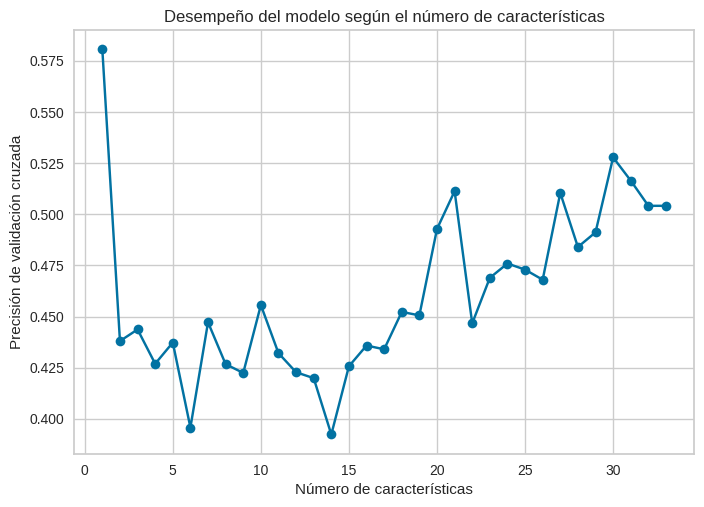

In [ ]:
from sklearn.metrics import make_scorer, precision_score

# Función para evaluar el desempeño del modelo con RFE
def evaluar_rfe(n_features):
    rfe = RFE(estimator=xgboost_rfe, n_features_to_select=n_features)
    rfe_pipeline = Pipeline(steps=[
        ('preprocessor', col_transformer),
        ('rfe', rfe)
    ])

    # Validación cruzada para evaluar el rendimiento con n características
    # Usar make_scorer para la precisión de la clase 1
    scorer = make_scorer(precision_score, pos_label=1)
    scores = cross_val_score(rfe_pipeline, X_train, y_train, cv=5, scoring=scorer)
    return scores.mean()

# Probar diferentes números de características (de 1 hasta 10 características)
import numpy as np
resultados_rfe = []
for n in range(1, len(columnas) + 1):
    score = evaluar_rfe(n)
    resultados_rfe.append((n, score))
    print(f"Desempeño con {n} características: {score:.4f}")

# Convertir los resultados a un array numpy para graficar
resultados_rfe = np.array(resultados_rfe)

# Graficar el desempeño según la cantidad de características seleccionadas
plt.plot(resultados_rfe[:, 0], resultados_rfe[:, 1], marker='o')
plt.xlabel('Número de características')
plt.ylabel('Precisión de validación cruzada')
plt.title('Desempeño del modelo según el número de características')
plt.show()

In [ ]:
# 4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

df_2 = df[['Reactions','label']]

clf = setup(data=df_2, target='label', session_id=42)

# Crear el modelo seleccionado (et)
final_model = create_model('xgboost')

# Evaluar el modelo
evaluate_model(final_model)


,Description,Value
0,Session id,42
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 2)"
4,Transformed data shape,"(17588, 2)"
5,Transformed train set shape,"(12311, 2)"
6,Transformed test set shape,"(5277, 2)"
7,Numeric features,1
8,Preprocess,True
9,Imputation type,simple


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9399,0.7533,0.0658,0.6250,0.1190,0.1086,0.1893
1,0.9399,0.7887,0.0800,0.5455,0.1395,0.1259,0.1923
2,0.9415,0.7123,0.0933,0.6364,0.1628,0.1495,0.2284
3,0.9383,0.7822,0.0667,0.4545,0.1163,0.1023,0.1563
4,0.9415,0.8022,0.0667,0.7143,0.1220,0.1127,0.2066
5,0.9374,0.7416,0.0667,0.4167,0.1149,0.0998,0.1476
6,0.9448,0.7156,0.1333,0.7692,0.2273,0.2131,0.3059
7,0.9391,0.7586,0.0667,0.5000,0.1176,0.1048,0.1661
8,0.9407,0.7481,0.0533,0.6667,0.0988,0.0906,0.1772


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Comparando el rendimiento obtenido con el nuevo modelo usando solamente `'Reactions'` podemos ver que las métricas son ligeramente inferiores en comparación al modelo anterior que contenía todas las variables. Lo anterior nos llama la antención dado que solamente estamos considerando la variable 'más importante' según las métricas del primer modelo, esperando que este nuevo modelo obtuviera mejores métricas.

5.
  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez?

    R: No, el rendimiento no es similar al modelo original con todas las características. En comparación con la precisión, el segundo modelo presenta un peor desempeño para clasificar la clase 1 (que es la más importante para Jere), dimisnuyendo la presición de **0.597** a **0.451**
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización.
  
    R: Los principales beneficios de eliminar variables en el modelo son:
    - **Simplificación del modelo**, que significa que el modelo es más fácil de interpretar y poder explicarlo. Incluyendo las características más importantes.
    - **Reducción de tiempo de entrenamiento**, al tener menos variable, el modelo es más rápido de generar.
    - **Mejora la capacidad de generalización**, eliminar variables que no sean relevantes para el modelo o redundantes puede disminuir el sobreajuste, mejorando así su desempeño.
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo.
  
    R: Este segundo modelo con menor dimensionalidad es más sencillo de explicar, dado que se enfoca únicamente en una sola variable (`'Reactions'`). La eliminación de ciertas características facilita la comprensión porque al tener menos variables que influyan en la predicción del modelo, es más fácil identificar aquellas que aporten más a la variable objetivo.

### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**